In [1]:
%load_ext autoreload
%autoreload 2

In [57]:
import matplotlib.pyplot as plt
from ariel_pred.config import CalibrationConfig, Config
from ariel_pred.dataset import DataLoaderAndCalibrator, LabelsLoader
from ariel_pred.preprocessing import SergeiDataSmoother
from ariel_pred.transit import WindowBasedPhaseDetector
from scipy.signal import savgol_filter
from ariel_pred.features import SergeiOldFeaturesExtractor
from ariel_pred.models import SegeiOldCNNTrainer, SergeiOldCNN
import numpy as np
import torch

In [3]:
global_config = Config()
calibration_config = CalibrationConfig(
    data_path=global_config.DATA_PATH,
    airs_lower_channel=0,
    airs_upper_channel=356,
    preprocessing_n_jobs=4,
)
signal_processor = DataLoaderAndCalibrator(cfg=calibration_config)
train_data = signal_processor.process_all_data("train")
test_data = signal_processor.process_all_data("test")
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

QUEUEING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/9 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

...

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Train data shape: (9, 5625, 357)
Test data shape: (1, 5625, 357)


In [4]:
data_smoother = SergeiDataSmoother(window_size=3)
smoothed_train_data = np.array([data_smoother.smooth(signal) for signal in train_data])

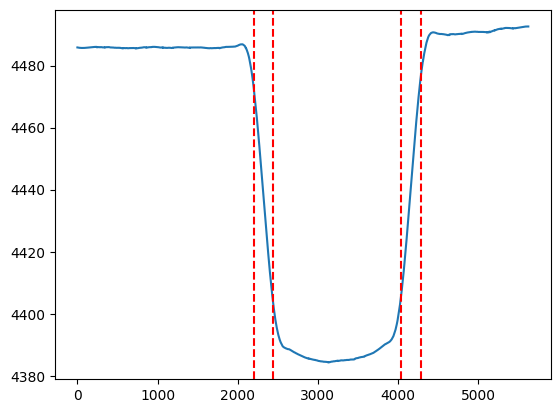

In [10]:
signal = smoothed_train_data[0].copy()
signal = signal.mean(axis=1)
signal = savgol_filter(signal, 330, 3)

transit_detector = WindowBasedPhaseDetector()
transit_drop_begin, transit_drop_end, transit_rise_begin, transit_rise_end = transit_detector.phase_detect(
    signal
)

plt.plot(signal)
plt.axvline(transit_drop_begin, color="red", linestyle="--")
plt.axvline(transit_drop_end, color="red", linestyle="--")
plt.axvline(transit_rise_begin, color="red", linestyle="--")
plt.axvline(transit_rise_end, color="red", linestyle="--")
plt.show()

In [11]:
print(f"Transit drop begin: {transit_drop_begin}")
print(f"Transit drop end: {transit_drop_end}")
print(f"Transit rise begin: {transit_rise_begin}")
print(f"Transit rise end: {transit_rise_end}")

Transit drop begin: 2200
Transit drop end: 2439
Transit rise begin: 4041
Transit rise end: 4280


In [12]:
smoothed_train_data.shape

(9, 5625, 283)

In [31]:
feature_extractor = SergeiOldFeaturesExtractor(phase_detector=transit_detector)
features = feature_extractor.extract_features(smoothed_train_data)

100%|██████████| 9/9 [00:14<00:00,  1.60s/it]


In [32]:
features.shape

(9, 283, 9)

In [35]:
labels_loader = LabelsLoader(base_data_path=str(global_config.DATA_PATH))
labels = labels_loader.load_labels()

In [ ]:
trainer = SegeiOldCNNTrainer(device=torch.device("mps"))
cnn_train_data = features.transpose(0, 2, 1)  # (n_samples, 9, 283)

In [55]:
trainer.train(cnn_train_data, labels, global_config.MODELS_DIR / "sergei_old")

Fold 1/5
Train Index: [2 3 4 5 6 7 8]
Train Index Type: int64
Data Type: float64
Train Data Shape: (7, 9, 283)


fold 1 train 1e-06 valid 1e-05 rmse 0.013815 ariel -1.2713267668007453e+25
Fold 2/5
Train Index: [0 1 4 5 6 7 8]
Train Index Type: int64
Data Type: float64
Train Data Shape: (7, 9, 283)


fold 2 train 3e-06 valid 0.0 rmse 0.007129 ariel -1227518.43877
Fold 3/5
Train Index: [0 1 2 3 6 7 8]
Train Index Type: int64
Data Type: float64
Train Data Shape: (7, 9, 283)


fold 3 train 3e-06 valid 1e-06 rmse 0.015144 ariel -1.7173015626900017e+25
Fold 4/5
Train Index: [0 1 2 3 4 5 8]
Train Index Type: int64
Data Type: float64
Train Data Shape: (7, 9, 283)


fold 4 train 3e-06 valid 0.0 rmse 0.008068 ariel -5.031501557164989e+24
Fold 5/5
Train Index: [0 1 2 3 4 5 6 7]
Train Index Type: int64
Data Type: float64
Train Data Shape: (8, 9, 283)
































































































































































































































































































































































Training SergeiOldCNN: 100%|██████████| 1000/1000 [00:25<00:00, 39.48it/s]

fold 5 train 3e-06 valid 1e-06 rmse 0.015171 ariel -1.7389921324588725e+25


In [50]:
torch.from_numpy(cnn_train_data[[0, 1, 4, 5, 6, 7, 8]]).float()

tensor([[[0.0223, 0.0223, 0.0223,  ..., 0.0223, 0.0223, 0.0223],
         [0.0224, 0.0224, 0.0224,  ..., 0.0221, 0.0221, 0.0221],
         [0.0224, 0.0224, 0.0224,  ..., 0.0220, 0.0220, 0.0220],
         ...,
         [0.0241, 0.0222, 0.0223,  ..., 0.0223, 0.0224, 0.0221],
         [0.0240, 0.0221, 0.0221,  ..., 0.0219, 0.0219, 0.0217],
         [0.0243, 0.0224, 0.0224,  ..., 0.0223, 0.0224, 0.0221]],

        [[0.0009, 0.0009, 0.0009,  ..., 0.0009, 0.0009, 0.0009],
         [0.0009, 0.0009, 0.0009,  ..., 0.0010, 0.0010, 0.0010],
         [0.0009, 0.0009, 0.0009,  ..., 0.0008, 0.0008, 0.0008],
         ...,
         [0.0021, 0.0010, 0.0009,  ..., 0.0019, 0.0019, 0.0020],
         [0.0023, 0.0009, 0.0009,  ..., 0.0017, 0.0016, 0.0016],
         [0.0023, 0.0009, 0.0009,  ..., 0.0019, 0.0019, 0.0020]],

        [[0.0209, 0.0209, 0.0209,  ..., 0.0209, 0.0209, 0.0209],
         [0.0208, 0.0208, 0.0208,  ..., 0.0211, 0.0211, 0.0211],
         [0.0208, 0.0208, 0.0208,  ..., 0.0211, 0.0211, 0.

In [58]:
model = SergeiOldCNN()
model.load_state_dict(torch.load(global_config.MODELS_DIR / "sergei_old" / "sergei_old_cnn_fold1.pth"))

<All keys matched successfully>

In [61]:
res = model(torch.tensor(cnn_train_data[[0, 1]]).float())

In [62]:
spectras, sigma = res

In [63]:
spectras.shape, sigma.shape

(torch.Size([2, 283]), torch.Size([2, 1]))

In [65]:
preds = spectras[0].detach().numpy()
actual = labels[0]

In [67]:
preds

array([0.01263066, 0.01486032, 0.01672771, 0.01808885, 0.01929045,
       0.02037083, 0.02122015, 0.0215082 , 0.02171054, 0.02185517,
       0.02195867, 0.02196667, 0.0219616 , 0.02193875, 0.02189832,
       0.02186572, 0.02184148, 0.02182228, 0.02180975, 0.02179939,
       0.02179156, 0.0217855 , 0.02178112, 0.02177903, 0.02177936,
       0.02178114, 0.02178425, 0.02178846, 0.02179335, 0.02179874,
       0.02180434, 0.02180988, 0.02181536, 0.02182056, 0.02182572,
       0.02183072, 0.02183569, 0.02184041, 0.02184526, 0.02184984,
       0.02185431, 0.02185849, 0.02186253, 0.02186617, 0.02186931,
       0.02187176, 0.02187373, 0.02187536, 0.02187635, 0.02187681,
       0.02187674, 0.02187591, 0.02187439, 0.02187186, 0.02186838,
       0.02186409, 0.02185876, 0.02185251, 0.02184509, 0.02183669,
       0.02182758, 0.02181771, 0.02180763, 0.02179699, 0.02178647,
       0.02177667, 0.02176776, 0.02175982, 0.02175293, 0.02174739,
       0.02174308, 0.02173952, 0.02173657, 0.02173412, 0.02173

In [72]:
np.abs(preds - actual).mean()

np.float64(0.0004445769918172238)